# Model Fitting

Use this notebook to train and compare sklearn models for ligand-to-metal binding affinity prediction. The feature set is configured in one place, the top 15 ligand covariates are chosen from the training split by absolute correlation with `Log K1`, and the fitted models are saved with predictions, residuals, metrics, feature importance summaries, and serialized model artifacts for later conformal prediction.


In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="talk")

DATA_SPLITS_ROOT = Path("../data/splits/Nd_3plus")
RESULTS_ROOT = Path("../results/model_fitting/Nd_3plus")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_ROOT = RESULTS_ROOT / "models"
MODELS_ROOT.mkdir(parents=True, exist_ok=True)

TARGET_COL = "Log K1"
METAL_COL = "Metal"
MOLECULE_COL = "Molecule"
ISOMER_COL = "Isomer"
RANDOM_SEED = 42
N_LIGAND_FEATURES = 15

RUN_CONFIG = {
    "metal": "Nd+++",
    "random_seed": RANDOM_SEED,
    "feature_selection": {
        "strategy": "top absolute Pearson correlation with Log K1 on the train split",
        "n_ligand_features": N_LIGAND_FEATURES,
    },
    "models": {
        "random_forest": {
            "display_name": "Random forest regressor",
            "uses_scaling": False,
            "parameters": {
                "n_estimators": 100,
                "random_state": RANDOM_SEED,
                "n_jobs": -1,
            },
        },
        "gradient_boosting": {
            "display_name": "Gradient boosting regressor",
            "uses_scaling": False,
            "parameters": {
                "n_estimators": 100,
                "learning_rate": 0.05,
                "max_depth": 3,
                "random_state": RANDOM_SEED,
            },
        },
        "lasso": {
            "display_name": "Lasso regression",
            "uses_scaling": True,
            "parameters": {
                "alpha": 0.001,
                "max_iter": 10000,
                "random_state": RANDOM_SEED,
            },
        },
        "ridge": {
            "display_name": "Ridge regression",
            "uses_scaling": True,
            "parameters": {
                "alpha": 1.0,
            },
        },
        "mlp": {
            "display_name": "Multilayer perceptron",
            "uses_scaling": True,
            "parameters": {
                "hidden_layer_sizes": [64, 32],
                "activation": "relu",
                "solver": "adam",
                "alpha": 0.0001,
                "learning_rate_init": 0.001,
                "max_iter": 1000,
                "early_stopping": True,
                "n_iter_no_change": 20,
                "random_state": RANDOM_SEED,
            },
        },
    },
}


def load_split(split_name: str) -> pd.DataFrame:
    split_path = DATA_SPLITS_ROOT / f"{split_name}.csv"
    frame = pd.read_csv(split_path)
    frame.columns = [column.strip() for column in frame.columns]
    frame[METAL_COL] = frame[METAL_COL].astype(str).str.strip()
    frame[MOLECULE_COL] = frame[MOLECULE_COL].astype(str).str.strip()
    frame[ISOMER_COL] = frame[ISOMER_COL].astype(str).str.strip()
    frame[TARGET_COL] = pd.to_numeric(frame[TARGET_COL], errors="coerce")
    return frame


def select_ligand_features(train_frame: pd.DataFrame, n_features: int) -> tuple[list[str], pd.DataFrame]:
    candidate_columns = [
        column
        for column in train_frame.columns
        if "(m)" in column
        and "_metal" not in column
        and "_medium" not in column
        and column not in {TARGET_COL, METAL_COL, MOLECULE_COL, ISOMER_COL}
    ]

    rows = []
    y = pd.to_numeric(train_frame[TARGET_COL], errors="coerce")
    for column in candidate_columns:
        x = pd.to_numeric(train_frame[column], errors="coerce")
        corr = x.corr(y)
        if pd.notna(corr):
            rows.append(
                {
                    "feature": column,
                    "pearson_corr": corr,
                    "abs_corr": abs(corr),
                }
            )

    ranking = pd.DataFrame(rows).sort_values(["abs_corr", "feature"], ascending=[False, True]).reset_index(drop=True)
    selected = ranking.head(n_features)["feature"].tolist()
    return selected, ranking


def collect_feature_sets(frame: pd.DataFrame, ligand_features: list[str]) -> dict[str, list[str]]:
    metal_features = [column for column in frame.columns if "_metal" in column]
    medium_features = [column for column in frame.columns if "_medium" in column]
    condition_features = [column for column in ["Temperature (K)", "Concentration (M)"] if column in frame.columns]

    ordered = ligand_features + metal_features + medium_features + condition_features
    unique_ordered = list(dict.fromkeys(ordered))
    return {
        "ligand_features": ligand_features,
        # "metal_features": metal_features,
        "medium_features": medium_features,
        "condition_features": condition_features,
        "all_features": unique_ordered,
    }


def make_pipeline(estimator, uses_scaling: bool) -> Pipeline:
    preprocess_steps = [("imputer", SimpleImputer(strategy="median"))]
    if uses_scaling:
        preprocess_steps.append(("scaler", StandardScaler()))

    return Pipeline(
        steps=[
            ("preprocess", Pipeline(preprocess_steps)),
            ("model", estimator),
        ]
    )


def build_estimator(model_name: str):
    parameters = RUN_CONFIG["models"][model_name]["parameters"].copy()
    if model_name == "random_forest":
        return RandomForestRegressor(**parameters)
    if model_name == "gradient_boosting":
        return GradientBoostingRegressor(**parameters)
    if model_name == "lasso":
        return Lasso(**parameters)
    if model_name == "ridge":
        return Ridge(**parameters)
    if model_name == "mlp":
        parameters["hidden_layer_sizes"] = tuple(parameters["hidden_layer_sizes"])
        return MLPRegressor(**parameters)
    raise KeyError(f"Unknown model: {model_name}")


def extract_feature_importance(fitted_pipeline: Pipeline, feature_columns: list[str], model_name: str, display_name: str) -> pd.DataFrame | None:
    model = fitted_pipeline.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        raw_values = np.asarray(model.feature_importances_, dtype=float)
    elif hasattr(model, "coef_"):
        raw_values = np.asarray(model.coef_, dtype=float).ravel()
    else:
        return None

    absolute_values = np.abs(raw_values)
    total = float(absolute_values.sum())
    normalized = absolute_values / total if total > 0 else absolute_values

    return pd.DataFrame(
        {
            "model": model_name,
            "display_name": display_name,
            "feature": feature_columns,
            "raw_value": raw_values,
            "absolute_value": absolute_values,
            "normalized_importance": normalized,
        }
    ).sort_values("normalized_importance", ascending=False)


def save_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2, sort_keys=True))


split_frames = {
    split_name: load_split(split_name)
    for split_name in ["train", "calibration_global", "calibration_local", "test"]
}
train_frame = split_frames["train"]

selected_ligand_features, ligand_ranking = select_ligand_features(train_frame, N_LIGAND_FEATURES)
feature_sets = collect_feature_sets(train_frame, selected_ligand_features)
feature_columns = feature_sets["all_features"]

save_json(
    RESULTS_ROOT / "run_config.json",
    {
        **RUN_CONFIG,
        "selected_ligand_features": selected_ligand_features,
        "feature_columns": feature_columns,
        "input_splits_root": str(DATA_SPLITS_ROOT),
        "results_root": str(RESULTS_ROOT),
    },
)

ligand_ranking.to_csv(RESULTS_ROOT / "ligand_feature_correlation_ranking.csv", index=False)
pd.DataFrame({"feature": feature_columns}).to_csv(RESULTS_ROOT / "selected_features.csv", index=False)

model_results = []
prediction_rows = []
importance_frames = []
model_fit_summaries = []
model_artifact_rows = []

for model_name, spec in RUN_CONFIG["models"].items():
    estimator = build_estimator(model_name)
    pipeline = make_pipeline(estimator, uses_scaling=spec["uses_scaling"])

    X_train = train_frame[feature_columns]
    y_train = train_frame[TARGET_COL]
    pipeline.fit(X_train, y_train)

    model_path = MODELS_ROOT / f"{model_name}.joblib"
    joblib.dump(pipeline, model_path)
    model_artifact_rows.append(
        {
            "model": model_name,
            "display_name": spec["display_name"],
            "model_path": str(model_path),
        }
    )

    split_metrics = {}
    for split_name, split_frame in split_frames.items():
        X_split = split_frame[feature_columns]
        y_split = split_frame[TARGET_COL].to_numpy(dtype=float)
        predictions = pipeline.predict(X_split)
        residuals = y_split - predictions

        prediction_rows.append(
            pd.DataFrame(
                {
                    "split": split_name,
                    "model": model_name,
                    "display_name": spec["display_name"],
                    "observed": y_split,
                    "predicted": predictions,
                    "residual": residuals,
                    "absolute_residual": np.abs(residuals),
                }
            )
        )

        split_metrics[split_name] = {
            "split": split_name,
            "model": model_name,
            "display_name": spec["display_name"],
            "mse": mean_squared_error(y_split, predictions),
            "residual_variance": float(np.var(residuals, ddof=0)),
        }

    model_fit_summaries.append(split_metrics["test"])

    importance = extract_feature_importance(
        fitted_pipeline=pipeline,
        feature_columns=feature_columns,
        model_name=model_name,
        display_name=spec["display_name"],
    )
    if importance is not None:
        importance_frames.append(importance)

predictions_df = pd.concat(prediction_rows, ignore_index=True)
test_metrics_df = pd.DataFrame(model_fit_summaries).sort_values("mse", ascending=True).reset_index(drop=True)
importance_df = pd.concat(importance_frames, ignore_index=True)
model_artifacts_df = pd.DataFrame(model_artifact_rows)

predictions_df.to_csv(RESULTS_ROOT / "predictions_and_residuals.csv", index=False)
test_metrics_df.to_csv(RESULTS_ROOT / "test_metrics.csv", index=False)
importance_df.to_csv(RESULTS_ROOT / "feature_importance.csv", index=False)
model_artifacts_df.to_csv(RESULTS_ROOT / "model_artifacts.csv", index=False)

print(test_metrics_df.to_string(index=False))


split             model                display_name      mse  residual_variance
 test     random_forest     Random forest regressor 3.089983           3.083956
 test gradient_boosting Gradient boosting regressor 3.978800           3.941442
 test               mlp       Multilayer perceptron 5.045754           5.037087
 test             lasso            Lasso regression 6.785353           6.785297
 test             ridge            Ridge regression 6.970411           6.970382


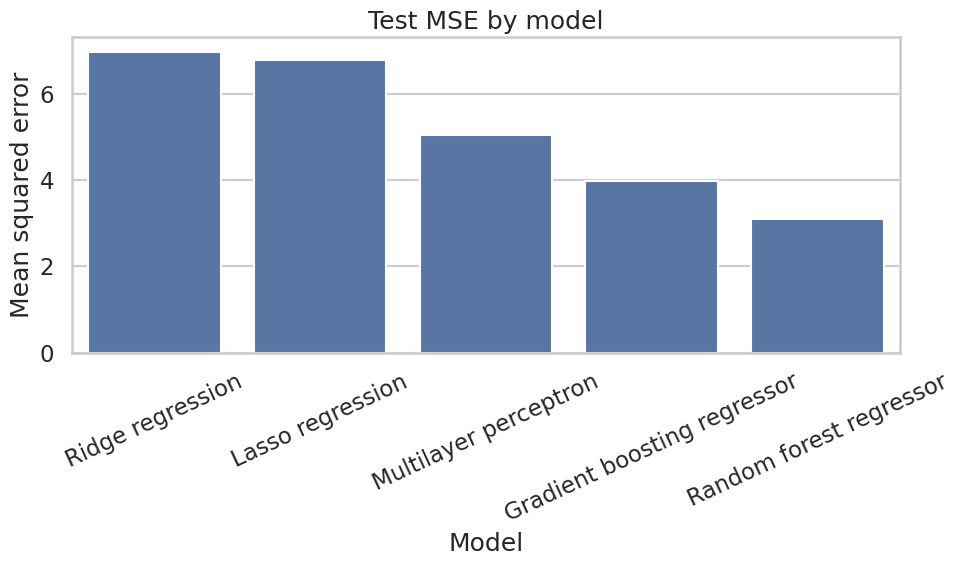

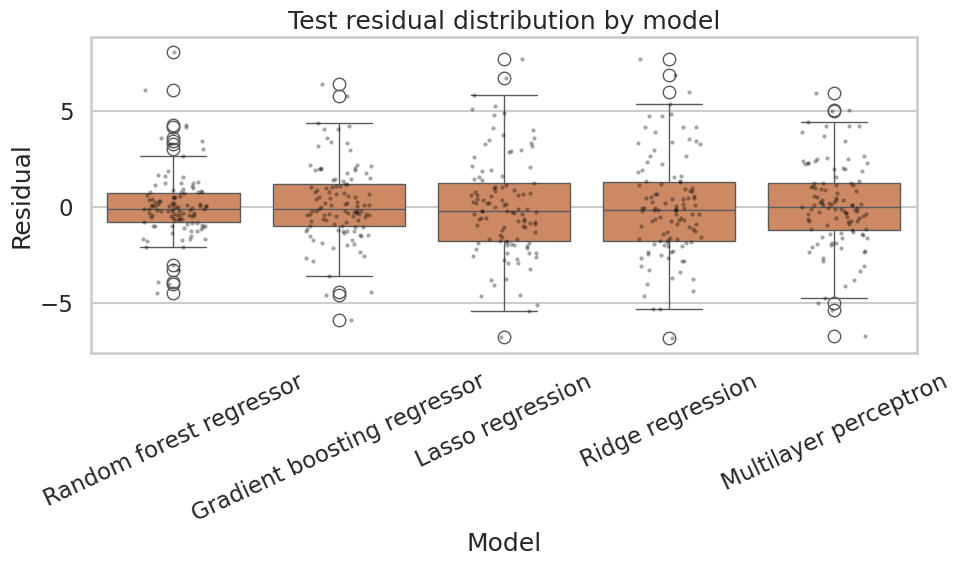

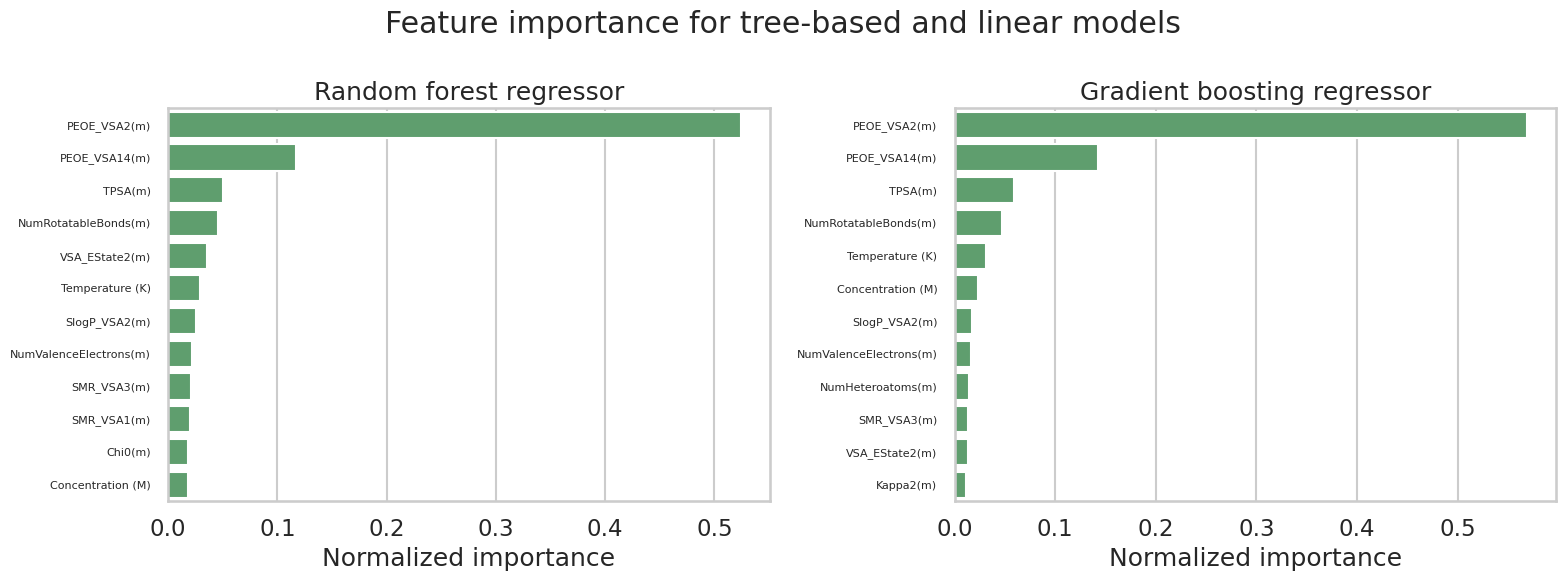

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = test_metrics_df.sort_values("mse", ascending=False)
sns.barplot(data=plot_df, x="display_name", y="mse", ax=ax, color="#4C72B0")
ax.set_title("Test MSE by model")
ax.set_xlabel("Model")
ax.set_ylabel("Mean squared error")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(RESULTS_ROOT / "test_mse_by_model.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
residual_plot_df = predictions_df.loc[predictions_df["split"] == "test"].copy()
sns.boxplot(data=residual_plot_df, x="display_name", y="residual", ax=ax, color="#DD8452")
sns.stripplot(data=residual_plot_df, x="display_name", y="residual", ax=ax, color="black", size=3, alpha=0.35, jitter=0.2)
ax.set_title("Test residual distribution by model")
ax.set_xlabel("Model")
ax.set_ylabel("Residual")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(RESULTS_ROOT / "test_residual_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

importance_plot_df = importance_df.loc[importance_df["model"].isin(["random_forest", "gradient_boosting", "lasso", "ridge"])].copy()
# importance_order = ["random_forest", "gradient_boosting", "lasso", "ridge"]
importance_order = ["random_forest", "gradient_boosting",]
# fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)
axes = axes.ravel()
for ax, model_name in zip(axes, importance_order):
    model_df = importance_plot_df.loc[importance_plot_df["model"] == model_name].sort_values("normalized_importance", ascending=False).head(12)
    sns.barplot(data=model_df, y="feature", x="normalized_importance", ax=ax, color="#55A868")
    ax.set_title(model_df["display_name"].iloc[0])
    ax.set_xlabel("Normalized importance")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Feature importance for tree-based and linear models")
fig.tight_layout()
fig.savefig(RESULTS_ROOT / "feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()


In [3]:
model_results = []
prediction_rows = []
importance_frames = []
model_fit_summaries = []

for model_name, spec in RUN_CONFIG["models"].items():
    estimator = build_estimator(model_name)
    pipeline = make_pipeline(estimator, uses_scaling=spec["uses_scaling"])

    X_train = train_frame[feature_columns]
    y_train = train_frame[TARGET_COL]
    pipeline.fit(X_train, y_train)

    split_metrics = {}
    for split_name, split_frame in split_frames.items():
        X_split = split_frame[feature_columns]
        y_split = split_frame[TARGET_COL].to_numpy(dtype=float)
        predictions = pipeline.predict(X_split)
        residuals = y_split - predictions

        prediction_rows.append(
            pd.DataFrame(
                {
                    "split": split_name,
                    "model": model_name,
                    "display_name": spec["display_name"],
                    "observed": y_split,
                    "predicted": predictions,
                    "residual": residuals,
                    "absolute_residual": np.abs(residuals),
                }
            )
        )

        split_metrics[split_name] = {
            "split": split_name,
            "model": model_name,
            "display_name": spec["display_name"],
            "mse": mean_squared_error(y_split, predictions),
            "residual_variance": float(np.var(residuals, ddof=0)),
        }

    model_fit_summaries.append(split_metrics["test"])

    importance = extract_feature_importance(
        fitted_pipeline=pipeline,
        feature_columns=feature_columns,
        model_name=model_name,
        display_name=spec["display_name"],
    )
    if importance is not None:
        importance_frames.append(importance)

predictions_df = pd.concat(prediction_rows, ignore_index=True)
test_metrics_df = pd.DataFrame(model_fit_summaries).sort_values("mse", ascending=True).reset_index(drop=True)
importance_df = pd.concat(importance_frames, ignore_index=True)

predictions_df.to_csv(RESULTS_ROOT / "predictions_and_residuals.csv", index=False)
test_metrics_df.to_csv(RESULTS_ROOT / "test_metrics.csv", index=False)
importance_df.to_csv(RESULTS_ROOT / "feature_importance.csv", index=False)

print(test_metrics_df.to_string(index=False))


split             model                display_name      mse  residual_variance
 test     random_forest     Random forest regressor 3.089983           3.083956
 test gradient_boosting Gradient boosting regressor 3.978800           3.941442
 test               mlp       Multilayer perceptron 5.045754           5.037087
 test             lasso            Lasso regression 6.785353           6.785297
 test             ridge            Ridge regression 6.970411           6.970382


In [4]:
split_frames = {
    split_name: load_split(split_name)
    for split_name in ["train", "calibration_global", "calibration_local", "test"]
}
train_frame = split_frames["train"]

selected_ligand_features, ligand_ranking = select_ligand_features(train_frame, N_LIGAND_FEATURES)
feature_sets = collect_feature_sets(train_frame, selected_ligand_features)
feature_columns = feature_sets["all_features"]

save_json(
    RESULTS_ROOT / "run_config.json",
    {
        **RUN_CONFIG,
        "selected_ligand_features": selected_ligand_features,
        "feature_columns": feature_columns,
        "input_splits_root": str(DATA_SPLITS_ROOT),
        "results_root": str(RESULTS_ROOT),
    },
)

ligand_ranking.to_csv(RESULTS_ROOT / "ligand_feature_correlation_ranking.csv", index=False)
pd.DataFrame({"feature": feature_columns}).to_csv(RESULTS_ROOT / "selected_features.csv", index=False)

print("Selected ligand features:")
for feature in selected_ligand_features:
    print(f"- {feature}")


Selected ligand features:
- PEOE_VSA2(m)
- NumRotatableBonds(m)
- PEOE_VSA14(m)
- NumHAcceptors(m)
- NOCount(m)
- SlogP_VSA2(m)
- VSA_EState2(m)
- NumHeteroatoms(m)
- TPSA(m)
- Kappa2(m)
- SMR_VSA3(m)
- SMR_VSA1(m)
- NumValenceElectrons(m)
- Chi0(m)
- EState_VSA10(m)
